In [1]:
import numpy as np
import pandas as pd
import argparse
import os
import json
import random
import pickle 
from tqdm import tqdm
import matplotlib.pylab as plt 

import copy
cp = lambda x: copy.deepcopy(x)

import torch

In [2]:
# country-capital data
df_name = "country"
df = pd.read_csv("data/countries.csv")[["name", "capital"]].dropna()
print('read:', len(df))
df.head()

read: 245


,name,capital
0,Afghanistan,Kabul
1,Aland Islands,Mariehamn
2,Albania,Tirana
3,Algeria,Algiers
4,American Samoa,Pago Pago


In [3]:
parser = argparse.ArgumentParser()
parser.add_argument("--exp_name", type=str)
parser.add_argument("--output_dir", type=str, default="./experiments/")
parser.add_argument("--seed", type=int, default=42)
parser.add_argument("--model_name", type=str, default="meta-llama/Llama-3.1-8B")

# args = parser.parse_args(args=['--exp_name', 'llama3.1', '--model_name', 'meta-llama/Llama-3.1-8B'])
# args = parser.parse_args(args=['--exp_name', 'pythia70m', '--model_name', 'EleutherAI/pythia-70m'])
# args = parser.parse_args(args=['--exp_name', 'pythia410m', '--model_name', 'EleutherAI/pythia-410m'])
# args = parser.parse_args(args=['--exp_name', 'gemma3.270m', '--model_name', 'google/gemma-3-270m'])
# args = parser.parse_args(args=['--exp_name', 'gemma2.2b', '--model_name', 'google/gemma-2-2b'])
# args = parser.parse_args(args=['--exp_name', 'gemma.2b', '--model_name', 'google/gemma-2b'])
# args = parser.parse_args(args=['--exp_name', 'gemma2.9b', '--model_name', 'google/gemma-2-9b'])
args = parser.parse_args(args=['--exp_name', 'phi2', '--model_name', 'microsoft/phi-2'])
# args = parser.parse_args(args=['--exp_name', 'phi1', '--model_name', 'microsoft/phi-1'])
# args = parser.parse_args(args=['--exp_name', 'qwen2.5.1.5b', '--model_name', 'Qwen/Qwen2.5-1.5B'])

print(args)

Namespace(exp_name='phi2', output_dir='./experiments/', seed=42, model_name='microsoft/phi-2')


In [4]:
output_dir = os.path.join(args.output_dir, args.exp_name)

dfile = os.path.join(output_dir, f"lens_{df_name}.pkl") 
with open(dfile, 'rb') as file:
    prompts    = pickle.load(file)
    answers    = pickle.load(file)
    hiddens    = pickle.load(file)
    ps_hiddens = pickle.load(file)
    rank_rg_, prob_rg_, nll_rg_, prob1_rg_, tok_rg_, rank_rg_2, prob_rg_2, nll_rg_2 = pickle.load(file)
    rank_ll_, prob_ll_, nll_ll_, prob1_ll_, tok_ll_, rank_ll_2, prob_ll_2, nll_ll_2 = pickle.load(file)
    rank_ps_, prob_ps_, nll_ps_, prob1_ps_, tok_ps_, rank_ps_2, prob_ps_2, nll_ps_2 = pickle.load(file)
    
    tokens_monitor = pickle.load(file)
    result_monitor_ll = pickle.load(file)
    result_monitor_ps = pickle.load(file)
    
    correct_tokens = pickle.load(file)  
        
print(f"loaded from {dfile} ({len(rank_rg_)})")

dfile = os.path.join(output_dir, f"geo_lens_{df_name}.pkl") 
with open(dfile, 'rb') as file:
    geo_hiddens = pickle.load(file)
    rank_geo_, prob_geo_, nll_geo_, prob1_geo_, tok_geo_, rank_geo_2, prob_geo_2, nll_geo_2 = pickle.load(file)  
    
    result_monitor_geo = pickle.load(file)
    
print(f"loaded from {dfile} ({len(rank_geo_)})")

loaded from ./experiments/phi2/lens_country.pkl (80)
loaded from ./experiments/phi2/geo_lens_country.pkl (80)


In [5]:
# top-X accuracy
print(np.mean(np.array(rank_rg_) == 0))
print(np.mean(np.array(rank_rg_) <= 1))
print(np.mean(np.array(rank_rg_) <= 3))
print(np.mean(np.array(rank_rg_) <= 5))
print(np.mean(np.array(rank_rg_) <= 20))

0.8875
0.9375
0.95
0.9625
0.975


In [6]:
idx = 72
print(tok_rg_[idx])
print('logit lens:')
print(tok_ll_[idx])
print('patchscopes:')
print(tok_ps_[idx])
print('geometric lens:')
print(tok_geo_[idx])

ĠParis
logit lens:
['nt', 'Ġnot', 'Ġalso', 'Ġalso', 'Ġalso', 'Ġalso', 'Ġalso', 'Ġalso', 'Ġalso', 'Ġalso', ':', ':', ':', ':', 'Ġcalled', ':', 'Ġcalled', 'Ġcalled', 'Ġcalled', 'Ġnot', ':', ':', ':', ':', 'ĠParis', 'ĠParis', 'ĠParis', 'ĠParis', 'ĠParis', 'ĠParis', 'ĠParis', 'ĠParis', 'ĠParis']
patchscopes:
['Ġ->', 'Ġa', 'Ġa', 'Ġthe', 'Ġthe', 'ĠParis', 'ĠParis', 'ĠParis', 'ĠParis', 'ĠParis', 'ĠParis', 'ĠParis', 'ĠParis', 'ĠParis', 'ĠParis', 'ĠParis', 'ĠParis', 'ĠParis', 'ĠParis', 'ĠParis', 'ĠParis', 'ĠParis', 'ĠParis', 'ĠParis', 'ĠParis', 'ĠParis', 'ĠParis', 'ĠParis', 'ĠParis', 'ĠParis', 'ĠParis', 'ĠParis']
geometric lens:
['Ġa', 'Ġnot', 'Ġa', 'Ġcalled', 'Ġthe', 'Ġin', 'Ġcalled', 'Ċ', 'a', 'Ġcalled', ',', '",', '......', '##', 'Question', '##', '##', '##', '##', '(', 'Paris', 'Paris', 'Paris', 'Paris', 'ĠParis', 'ĠParis', 'ĠParis', 'ĠParis', 'ĠParis', 'ĠParis', 'ĠParis', 'ĠParis']


### Train LAE

In [7]:
lm_head_path = os.path.join(args.output_dir, args.exp_name, 'lm_head.pkl')
with open(lm_head_path, 'rb') as file:
    weight = pickle.load(file)
    bias = pickle.load(file)
    id_to_token = pickle.load(file)
print('> loaded from', lm_head_path)
print(weight.shape)
print(bias.shape)

> loaded from ./experiments/phi2/lm_head.pkl
(51200, 2560)
(51200,)


In [8]:
idx = 72

paths = [hiddens[idx][1:,:], ps_hiddens[idx], geo_hiddens[idx]]
for p in paths:
    print(p.shape)

(32, 2560)
(32, 2560)
(32, 2560)


In [9]:
# prepare data and PD
num_rows = 32
num_cols = 3

data = {
    (i, j): torch.from_numpy(paths[j][i].astype(np.float32))
    for i in range(num_rows) for j in range(num_cols)
}

classifier_weight = torch.from_numpy(weight)
classifier_bias = torch.from_numpy(bias)

print('data:', data[(0,0)].shape, 'weight & bias:', classifier_weight.shape, classifier_bias.shape)

data: torch.Size([2560]) weight & bias: torch.Size([51200, 2560]) torch.Size([51200])


In [10]:
from autoencoder_ce import AEConfig, train, plot_loss_curves, encode_points, _make_dummy_data

Epoch    1/50  |  total=184.5322  recon=1.3190  ce=9.1607
Epoch    5/50  |  total=44.4710  recon=0.4973  ce=2.1987
Epoch   10/50  |  total=42.2051  recon=0.3088  ce=2.0948
Epoch   15/50  |  total=38.2675  recon=0.2426  ce=1.9012
Epoch   20/50  |  total=37.2367  recon=0.2238  ce=1.8506
Epoch   25/50  |  total=35.1254  recon=0.1862  ce=1.7470
Epoch   30/50  |  total=34.9351  recon=0.1543  ce=1.7390
Epoch   35/50  |  total=34.1509  recon=0.1539  ce=1.6999
Epoch   40/50  |  total=35.9303  recon=0.1627  ce=1.7884
Epoch   45/50  |  total=41.3848  recon=0.1910  ce=2.0597
Epoch   50/50  |  total=34.5833  recon=0.1320  ce=1.7226


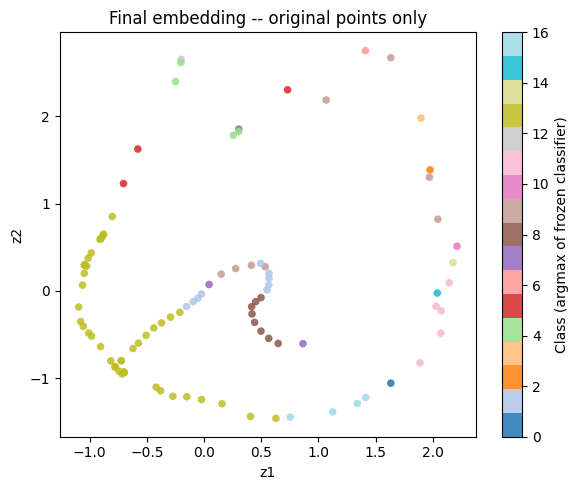

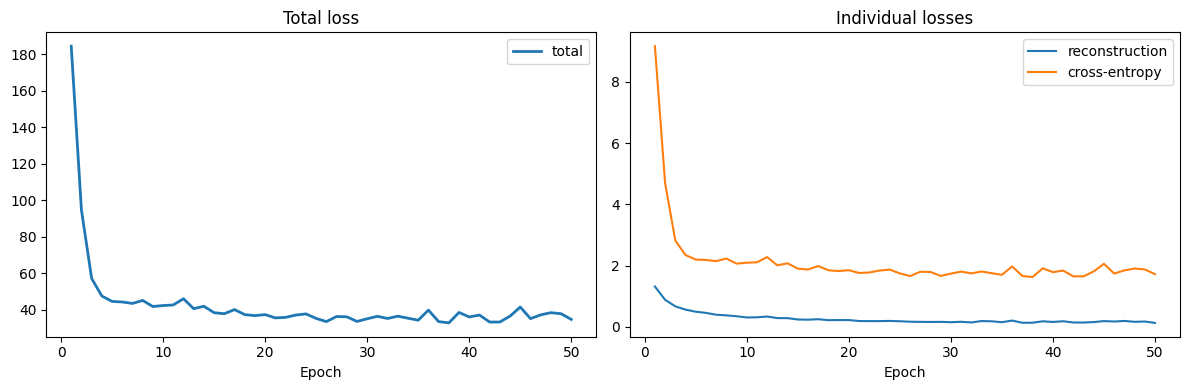

In [11]:
cfg = AEConfig(
    # Data
    input_dim       = data[(0,0)].shape[0],
    num_rows        = num_rows,
    num_cols        = num_cols,

    # Sampling
    samples_per_cell = 0,      # synthetic points per 2×2 cell per epoch
    dirichlet_alpha  = 2.0,    # >1 = mostly inside simplex; lower = pushes to corners
    extrap_std       = 0.05,   # Gaussian noise → mild extrapolation outside simplex

    # Architecture
    hidden_dims  = [512, 128, 32], # [512, 128, 32] [512, 128]
    norm         = "batchnorm",   # "layernorm" | "batchnorm" | "none"
    activation   = "relu",        # "gelu" | "relu"

    # kNN
    k_neighbors  = 3,

    # Loss weights
    lambda_recon    = 1.0,
    lambda_neighbor = 0.00,
    lambda_ce       = 20.0,

    # Training
    batch_size = 32,
    lr         = 1e-3,
    epochs     = 50,
    plot_every = 50,    # scatter plot every N epochs; 0 = only at end
    
    device = "cpu",
)

model, history = train(data, classifier_weight, classifier_bias, cfg)
plot_loss_curves(history)

In [12]:
# original data points, latents
from autoencoder_ce import FrozenClassifier

device = cfg.device
classifier = FrozenClassifier(classifier_weight, classifier_bias).to(device)

X_orig_np = np.stack(
    [np.asarray(data[(i, j)], dtype=np.float32)
        for i in range(cfg.num_rows) for j in range(cfg.num_cols)
        if (i, j) in data],
    axis=0,
)
X_orig = torch.tensor(X_orig_np, dtype=torch.float32, device=device)
with torch.no_grad():
    probs_orig = classifier(X_orig)

model.eval()
with torch.no_grad():
    z = model.encode(X_orig).cpu().numpy()           # (N, 2)
classes = probs_orig.argmax(dim=-1).cpu().numpy()    # (N,)
# note: classes are the real labels, not AE labels!

In [13]:
# re-map the class IDs
_, ranks = np.unique(classes, return_inverse=True) # keep full list length, return orders
rank2id = {r:c for r,c in zip(ranks.tolist(), classes.tolist())}
id2rank = {c:r for r,c in zip(ranks.tolist(), classes.tolist())}

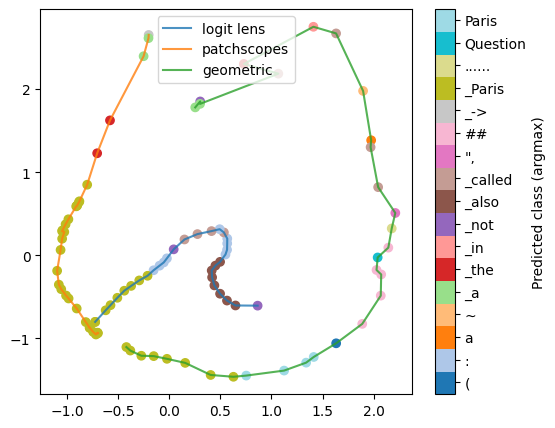

In [14]:
# plot 2D
_, ranks = np.unique(classes, return_inverse=True)
n_classes = int(ranks.max()) + 1
cmap = plt.colormaps.get_cmap("tab20").resampled(n_classes) if n_classes <= 20 else plt.colormaps.get_cmap("nipy_spectral").resampled(n_classes)

fig, ax = plt.subplots(figsize=(6,5))
sc = ax.scatter(z[:, 0], z[:, 1], c=ranks, cmap=cmap)
cbar = plt.colorbar(sc, ax=ax, label="Predicted class (argmax)")

labels = []
for c in range(n_classes):
    labels.append(id_to_token[rank2id[c]].replace('Ġ', '_').replace('Ċ', '~'))

tick_locs = np.arange(n_classes) / n_classes * (n_classes-1) + 0.5
cbar.set_ticks(tick_locs)
cbar.set_ticklabels(labels)

lbs = ['logit lens', 'patchscopes', 'geometric']
for t in range(3): # all last paths of all runs
    idt = [idx for idx,k in enumerate(data.keys()) if k[1]==t]    
    ax.plot(*z[idt].T, alpha=0.8, label=lbs[t])
ax.legend()

In [15]:
print('regular:', tok_rg_)
print('logit lens:', tok_ll_)
print('patchscopes:', tok_ps_)
print('geometric lens:', tok_geo_)

regular: ['ĠKabul', 'Ġthe', 'ĠTir', 'ĠAl', 'ĠP', 'ĠAnd', 'ĠLu', 'ĠThe', 'ĠSt', 'ĠBuenos', 'ĠY', 'ĠOr', 'ĠCanberra', 'ĠVienna', 'ĠB', 'ĠMan', 'ĠDh', 'ĠBr', 'ĠM', 'ĠBrussels', 'ĠBel', 'ĠC', 'ĠHamilton', 'ĠTh', 'ĠLa', 'ĠWil', 'ĠSar', 'ĠG', 'ĠBras', 'ĠPort', 'ĠBand', 'ĠSof', 'ĠOu', 'ĠBu', 'ĠPh', 'ĠYa', 'ĠOttawa', 'ĠPra', 'ĠGeorge', 'ĠB', 'ĠN', 'ĠSantiago', 'ĠBeijing', 'ĠChristmas', 'Ġthe', 'ĠBog', 'ĠMor', 'ĠK', 'ĠR', 'ĠSan', 'ĠZ', 'ĠHavana', 'ĠWil', 'ĠNic', 'ĠPrague', 'ĠK', 'ĠCopenhagen', 'ĠDj', 'ĠRose', 'ĠSant', 'ĠQu', 'ĠCairo', 'ĠSan', 'ĠMal', 'ĠAs', 'ĠTall', 'ĠMb', 'ĠAdd', 'ĠStanley', 'ĠT', 'ĠSu', 'ĠHelsinki', 'ĠParis', 'ĠCay', 'ĠP', 'ĠPort', 'ĠLibre', 'ĠT', 'ĠBerlin', 'ĠAcc']
logit lens: [['nt', 'Ġalso', 'Ġalso', 'Ġalso', 'Ġalso', 'Ġalso', 'Ġnot', 'Ġalso', 'Ġestimated', 'Ġestimated', ':', 'Ġcurrently', 'Ġcalled', 'Ġcalled', 'Ġcalled', 'Ġcalled', 'Ġalso', 'Ġcalled', 'Ġnot', 'Ġnot', 'Ġalso', ':', ':', ':', 'Ġ__', 'ĠKabul', 'ĠKabul', 'ĠKabul', 'ĠKabul', 'ĠKabul', 'ĠKabul', 'ĠKabul', 'ĠKab

### Plot regions

In [16]:
# ── Subdivision / partition plot ──────────────────────────────────────────────
res = 150  # grid resolution (argument-ify via cfg if needed)

# Canvas range with a small margin
margin = 0.05
x1_min, x1_max = z[:, 0].min(), z[:, 0].max()
x2_min, x2_max = z[:, 1].min(), z[:, 1].max()
x1_min -= margin * (x1_max - x1_min)
x1_max += margin * (x1_max - x1_min)
x2_min -= margin * (x2_max - x2_min)
x2_max += margin * (x2_max - x2_min)

# Regular 2D grid in latent space
g1, g2 = np.meshgrid(np.linspace(x1_min, x1_max, res),
                      np.linspace(x2_min, x2_max, res))
grid_z = torch.tensor(
    np.stack([g1.ravel(), g2.ravel()], axis=1),
    dtype=torch.float32, device=next(model.parameters()).device,
)

# Decode grid points -> classify -> get labels
with torch.no_grad():
    grid_x_hat  = model.decode(grid_z)               # (res*res, D)
    grid_logits = classifier(grid_x_hat)              # (res*res, C)
    grid_labels = grid_logits.argmax(-1).cpu().numpy()


In [17]:
# re-map the class IDs
classes = np.unique(grid_labels)
_, ranks = np.unique(classes, return_inverse=True)
rank2id = {r:c for r,c in zip(ranks.tolist(), classes.tolist())}
id2rank = {c:r for r,c in zip(ranks.tolist(), classes.tolist())}

n_classes = int(ranks.max()) + 1
print(n_classes)
cmap = plt.colormaps.get_cmap("tab20").resampled(n_classes) if n_classes <= 20 else plt.colormaps.get_cmap("nipy_spectral").resampled(n_classes)

mapper = np.vectorize(lambda x: id2rank.get(x, np.nan), otypes=[float]) # if it's not in id2rank (original training points label set), it's nan
grid_ = mapper(grid_labels)
grid_ = grid_.reshape(res, res)

16


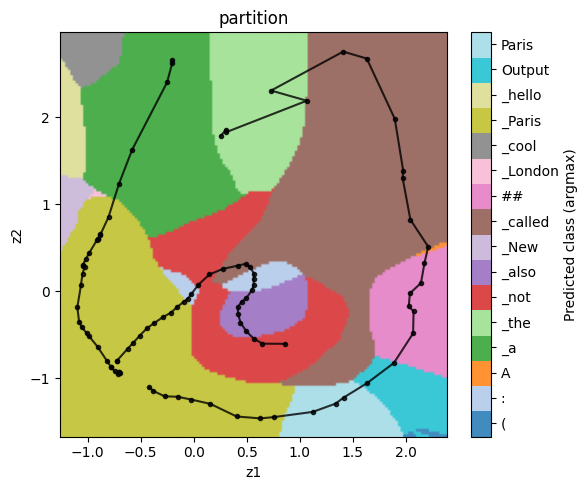

In [18]:
fig2, ax2 = plt.subplots(figsize=cfg.figsize)
sc = ax2.imshow(grid_, origin="lower", aspect="auto",
           extent=[x1_min, x1_max, x2_min, x2_max],
           cmap=cmap, alpha=0.85)

for t in range(3): # a range of one run
    idt = [idx for idx,k in enumerate(data.keys()) if k[1]==t]    
    ax2.plot(*z[idt].T, marker='.', color='k', alpha=0.8)
cbar = plt.colorbar(sc, ax=ax2, label="Predicted class (argmax)")
labels = []
for c in range(n_classes):
    labels.append(id_to_token[rank2id[c]].replace('Ġ', '_').replace('Ċ', '~'))
tick_locs = np.arange(n_classes) / n_classes * (n_classes-1) + 0.5
cbar.set_ticks(tick_locs)
cbar.set_ticklabels(labels)

ax2.set_title("partition")
ax2.set_xlabel("z1")
ax2.set_ylabel("z2")
plt.tight_layout()
plt.show()